In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
%matplotlib inline
import getdist
from getdist import loadMCSamples, plots
import warnings
from copy import deepcopy

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# GENERAL PLOT OPTIONS
# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['ytick.major.size'] = 6
matplotlib.rcParams['ytick.major.width'] = 1.2
matplotlib.rcParams['ytick.minor.size'] = 3
matplotlib.rcParams['ytick.minor.width'] = 0.8
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 24
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['legend.fontsize'] = 14
matplotlib.rcParams['legend.title_fontsize'] = 18
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.dpi'] = 300

columnwidth=246/72.27
textwidth=510/72.27

matplotlib.rcParams['axes.titlesize'] = 10
matplotlib.rcParams['axes.labelsize'] = 10
matplotlib.rcParams['legend.fontsize'] = 10
matplotlib.rcParams['legend.title_fontsize'] = 10
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10

from scipy.interpolate import interp1d
from scipy.integrate import quad

In [2]:

choice = 0
filepaths = [
    './data/roman_real/roman_lcdm_baseline_mcmc/',
    './data/roman_real/roman_lcdm_limber_mcmc/',
    './data/roman_real/roman_lcdm_noRSD_mcmc/',
    './data/roman_real/roman_lcdm_hmcode20_mcmc/',
    './data/roman_real/roman_lcdm_limber_noRSD_hmcode20_mcmc/',

    './data/roman_fourier/roman_lcdm_baseline_mcmc/',
    './data/roman_fourier/roman_lcdm_limber_mcmc/',
    './data/roman_fourier/roman_lcdm_noRSD_mcmc/',
    './data/roman_fourier/roman_lcdm_hmcode20_mcmc/',
    './data/roman_fourier/roman_lcdm_limber_noRSD_hmcode20_mcmc/',

    './data/lsst_real/lsst_lcdm_baseline_mcmc/',
    './data/lsst_real/lsst_lcdm_limber_mcmc/',
    './data/lsst_real/lsst_lcdm_noRSD_mcmc/',
    './data/lsst_real/lsst_lcdm_hmcode20_mcmc/',
    './data/lsst_real/lsst_lcdm_limber_noRSD_hmcode20_mcmc/',

    './data/lsst_fourier/lsst_lcdm_baseline_mcmc/',
    './data/lsst_fourier/lsst_lcdm_limber_mcmc/',
    './data/lsst_fourier/lsst_lcdm_noRSD_mcmc/',
    './data/lsst_fourier/lsst_lcdm_hmcode20_mcmc/',
    './data/lsst_fourier/lsst_lcdm_limber_noRSD_hmcode20_mcmc/',
    ]
labels = ['Baseline (non-\n Limber+RSD+EE2)',
          'Limber',
          'noRSD',
          'HMcode',
          'Limber+\n noRSD+HMcode20']
cmap = plt.get_cmap("viridis")
colors = [tuple(cmap(x)) for x in np.linspace(0, 1, len(labels))]
def load(filepath, settings):
    samples = loadMCSamples(filepath, settings=settings)
    #samples.thin(50)
    
    #indxs = samples.random_single_samples_indices(max_samples=20000, random_state=0)
    #loglikes = None if samples.loglikes is None else samples.loglikes[indxs]
    #samples.setSamples(samples.samples[indxs], weights=None, loglikes=loglikes)
    
    p = samples.getParams()
    s8 = p.sigma8*(p.omegam/0.3)**0.5
    try:
        samples.addDerived(
            s8,
            'S8',
            label = r'S_8',
        )
    except:
        True
    return samples
settings = {'ignore_rows':0.2, 'contours': [0.68, 0.95]}
samples = []
for i in range(len(filepaths)):
    samples.append(load(filepaths[i], settings = settings))
    # clear wrong latex
    pn = samples[-1].getParamNames()
    latex_As = r'10^{9} A_{\rm s}'
    for p in pn.names:
        if p.name == 'mnu':
            p.label = r'm_{\nu}'
        if p.name.lower() == 'omegan':
            p.label = r'\Omega_{\nu}'
        if p.name == 'As_1e9':
            p.label = latex_As
fiducials ={
    'As_1e9': 2.1,
    'ns': 0.96605,
    'H0': 67.32,
    'omegab': 0.0495,
    'omegam': 0.316,
    'sigma8': 0.81164266,
    'mnu': 0.06,
    'w': -1.0,
    'roman_DZ_S1': 0.0,
    'roman_DZ_S2': 0.0,
    'roman_DZ_S3': 0.0,
    'roman_DZ_S4': 0.0,
    'roman_DZ_S5': 0.0,
    'roman_DZ_S6': 0.0,
    'roman_DZ_S7': 0.0,
    'roman_DZ_S8': 0.0,
    
    'roman_DZ_L1': 0.0,
    'roman_DZ_L2': 0.0,
    'roman_DZ_L3': 0.0,
    'roman_DZ_L4': 0.0,
    'roman_DZ_L5': 0.0,
    'roman_DZ_L6': 0.0,
    'roman_DZ_L7': 0.0,
    'roman_DZ_L8': 0.0,
    'roman_DZ_L9': 0.0,
    'roman_DZ_L10': 0.0,
    
    'roman_M1': 0.0,
    'roman_M2': 0.0,
    'roman_M3': 0.0,
    'roman_M4': 0.0,
    'roman_M5': 0.0,
    'roman_M6': 0.0,
    'roman_M7': 0.0,
    'roman_M8': 0.0,
    
    'roman_A1_1': 0.5,
    'roman_A1_2': 0.0,
    'roman_A2_1': 0.0,
    'roman_A2_2': 0.0,
    'roman_BTA_1': 0.0,
    
    'roman_B1_1': 1.09,
    'roman_B1_2': 1.15,
    'roman_B1_3': 1.21,
    'roman_B1_4': 1.27,
    'roman_B1_5': 1.33,
    'roman_B1_6': 1.40,
    'roman_B1_7': 1.46,
    'roman_B1_8': 1.53,
    'roman_B1_9': 1.60,
    'roman_B1_10': 1.67,

    'lsst_DZ_S1': 0.0,
    'lsst_DZ_S2': 0.0,
    'lsst_DZ_S3': 0.0,
    'lsst_DZ_S4': 0.0,
    'lsst_DZ_S5': 0.0,
    'lsst_DZ_S6': 0.0,
    'lsst_DZ_S7': 0.0,
    'lsst_DZ_S8': 0.0,
    
    'lsst_DZ_L1': 0.0,
    'lsst_DZ_L2': 0.0,
    'lsst_DZ_L3': 0.0,
    'lsst_DZ_L4': 0.0,
    'lsst_DZ_L5': 0.0,
    'lsst_DZ_L6': 0.0,
    'lsst_DZ_L7': 0.0,
    'lsst_DZ_L8': 0.0,
    'lsst_DZ_L9': 0.0,
    'lsst_DZ_L10': 0.0,
    
    'lsst_M1': 0.0,
    'lsst_M2': 0.0,
    'lsst_M3': 0.0,
    'lsst_M4': 0.0,
    'lsst_M5': 0.0,
    'lsst_M6': 0.0,
    'lsst_M7': 0.0,
    'lsst_M8': 0.0,
    
    'lsst_A1_1': 0.5,
    'lsst_A1_2': 0.0,
    'lsst_A2_1': 0.0,
    'lsst_A2_2': 0.0,
    'lsst_BTA_1': 0.0,
    
    'lsst_B1_1': 1.09,
    'lsst_B1_2': 1.15,
    'lsst_B1_3': 1.21,
    'lsst_B1_4': 1.27,
    'lsst_B1_5': 1.33,
    'lsst_B1_6': 1.40,
    'lsst_B1_7': 1.46,
    'lsst_B1_8': 1.53,
    'lsst_B1_9': 1.60,
    'lsst_B1_10': 1.67,
}


fiducials['S8'] = fiducials['sigma8']*(fiducials['omegam']/0.3)**0.5


./data/roman_real/roman_lcdm_noRSD_mcmc/1.txt
./data/roman_real/roman_lcdm_noRSD_mcmc/2.txt
./data/roman_real/roman_lcdm_noRSD_mcmc/3.txt
./data/roman_real/roman_lcdm_noRSD_mcmc/4.txt
Removed 0.2 as burn in
./data/roman_fourier/roman_lcdm_noRSD_mcmc/1.txt
./data/roman_fourier/roman_lcdm_noRSD_mcmc/2.txt
./data/roman_fourier/roman_lcdm_noRSD_mcmc/3.txt
./data/roman_fourier/roman_lcdm_noRSD_mcmc/4.txt
Removed 0.2 as burn in
./data/lsst_real/lsst_lcdm_noRSD_mcmc/1.txt
./data/lsst_real/lsst_lcdm_noRSD_mcmc/2.txt
./data/lsst_real/lsst_lcdm_noRSD_mcmc/3.txt
./data/lsst_real/lsst_lcdm_noRSD_mcmc/4.txt
Removed 0.2 as burn in
./data/lsst_fourier/lsst_lcdm_noRSD_mcmc/1.txt
./data/lsst_fourier/lsst_lcdm_noRSD_mcmc/2.txt
./data/lsst_fourier/lsst_lcdm_noRSD_mcmc/3.txt
./data/lsst_fourier/lsst_lcdm_noRSD_mcmc/4.txt
Removed 0.2 as burn in


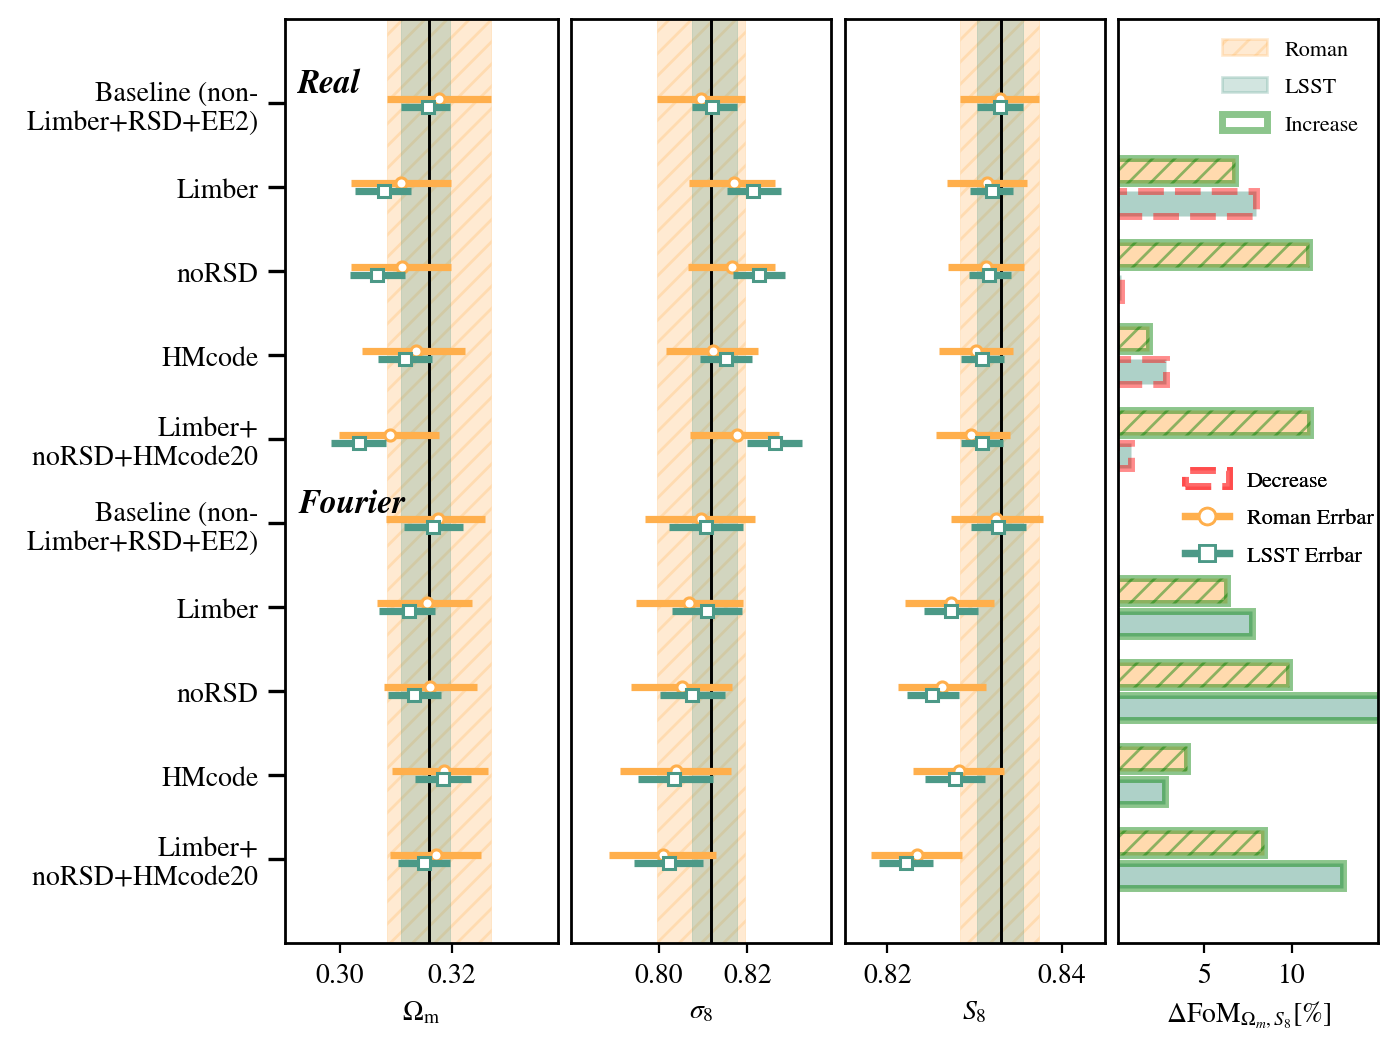

In [3]:
res0 = 0
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import transforms

def plot_row(axs, labels, samples, params):
    
    assert len(axs)==len(params)+1

    Nsample = 5
    height = 0.3
    dy = 0.05

    nparam = len(params)
    ys = np.arange(Nsample*2)[::-1]
    
    # set the labels of chains
    axs[0].set_yticks(ys)
    axs[0].set_yticklabels(labels+labels)
    
    for i in range(1,len(axs)):
        axs[i].set_yticks(ys)
        axs[i].tick_params(axis='y', left=False)
        axs[i].set_yticklabels([])
        axs[i].set_ylim(ys[-1]-1, ys[0]+1)

    ax0 = axs[0]
    trans = transforms.blended_transform_factory(ax0.transAxes, ax0.transData)
    ax0.text(0.05, ys[0] + 0.23, "Real", transform=trans, va='center', ha='left', clip_on=False, zorder=5, fontstyle='italic', fontweight='bold',fontsize=12)
    ax0.text(0.05, ys[5] + 0.23, "Fourier", transform=trans, va='center', ha='left', zorder=5, fontstyle='italic', fontweight='bold',fontsize=12)

    roman_color = '#FFAF4C'
    lsst_color  = '#4C9987'
    roman_ls = '-'     # error bar 线型
    lsst_ls  = '-'
    roman_marker = 'o'
    lsst_marker  = 's'
    roman_hatch = '///'  # baseline vspan hatch
    lsst_hatch  = None
             
    # plot the error bar
    for i in range(len(samples)):
        
        is_roman = (i < 10)  # 0-10 Roman, 10-20 LSST
        color = roman_color if is_roman else lsst_color
        
        if i%(Nsample*2) == 0:
            for j in range(nparam):
                p = params[j]
                stat = samples[i].getMargeStats().parWithName(p)
                mean = stat.mean
                upper_bound = stat.limits[0].upper
                lower_bound = stat.limits[0].lower

                hatch = roman_hatch if is_roman else lsst_hatch

                span=axs[j].axvspan(
                    lower_bound, upper_bound,
                    facecolor=color, alpha=0.25,
                    hatch=hatch, edgecolor=color, linewidth=0.3,
                    zorder=0
                    )
                span.set_rasterized(True)
                #axs[j].axvline(mean, color=color, lw=1, alpha=0.8, zorder=0)
                axs[j].axvline(fiducials[p], color='k',lw=1,alpha=1,zorder=0)
                axs[j].set_xlim(mean-3*(mean-lower_bound), mean+3*(upper_bound-mean))
                axs[j].set_ylim(ys[-1]-1, ys[0]+1)
        
        sample = samples[i]
        y0 = ys[i%(2*Nsample)]
        y = y0 + (dy if is_roman else -dy)

        ls = roman_ls if is_roman else lsst_ls
        marker = roman_marker if is_roman else lsst_marker
        
        c = color
        lw = 2.6
        edge_color = 'k' if i%Nsample==0 else 'none'
        for j in range(len(params)):
            ax = axs[j]
            p = params[j]
            stat = sample.getMargeStats().parWithName(p)
            mean = stat.mean
            upper_bound = stat.limits[0].upper
            lower_bound = stat.limits[0].lower
            
            ax.hlines(y, lower_bound, upper_bound, color=c, lw=lw, linestyle=ls)
            ax.plot(mean,y,marker=marker,mfc='white',mec=c,mew=1.1,ms=4,linestyle='None')
            
            #set x-axis
            if i==0:
                ax.set_xlabel(sample.getParamNames().parWithName(p).latexLabel())

        #now get the estimation of FoM
        p1 = params[0]
        p2 = params[2]
        names = [n.name for n in sample.getParamNames().names]
        a, b = names.index(p1), names.index(p2)
        cov = sample.getCov(pars=[a,b])
        det = np.linalg.det(cov)
        res = np.nan if det <= 0 or not np.isfinite(det) else 1.0 / np.sqrt(det)

        if i%Nsample==0:
            res0 = res
        else:
            bias = +height/2 if i<10 else -height/2
            if res-res0>0:
                axs[-1].barh(y+bias, (res-res0)/res0*100, height=height, alpha=0.45, color=color, hatch=hatch, edgecolor='green', linewidth=2.5,linestyle='-')
            elif res-res0<0:
                axs[-1].barh(y+bias, np.abs(res-res0)/res0*100, height=height, alpha=0.45, color=color, hatch=hatch, edgecolor='red', linewidth=2.5,linestyle='--')
        
        #set x-axis for FoM
        if i==0:
            axs[-1].set_xlabel(r'$ \Delta \mathrm{FoM}_{\Omega_m, S_8} [\%]$')

    legend_handles = [
    Patch(facecolor=roman_color, alpha=0.25, hatch=roman_hatch, edgecolor=roman_color, label='Roman'),
    Patch(facecolor=lsst_color,  alpha=0.25, hatch=lsst_hatch,  edgecolor=lsst_color,  label='LSST'),
    Patch(facecolor='w', alpha=0.45, edgecolor='green', linewidth=2.5,linestyle='-', label='Increase'),
    Patch(facecolor='w',  alpha=0.45,  edgecolor='red', linewidth=2.5,linestyle='--', label='Decrease'),
    Line2D([0],[0], color=roman_color, lw=lw, linestyle=roman_ls, marker=roman_marker, mfc='white', label='Roman Errbar'),
    Line2D([0],[0], color=lsst_color,  lw=lw, linestyle=lsst_ls,  marker=lsst_marker,  mfc='white', label='LSST Errbar'),
    ]
    leg1 = axs[-1].legend(handles=legend_handles[:int(len(legend_handles)/2)], loc='upper right', frameon=False, fontsize=8,ncol=1)
    axs[-1].add_artist(leg1)
    leg1.set_rasterized(True)
    leg2 = axs[-1].legend(handles=legend_handles[int(len(legend_handles)/2):], loc='center right', frameon=False, fontsize=8,ncol=1, bbox_to_anchor=(1.06, 0.46))
    axs[-1].add_artist(leg2)
    leg2.set_rasterized(True)
    
fig = plt.figure(figsize = (textwidth, 6))
gs = fig.add_gridspec(1,4,width_ratios=[1.05, 1.0, 1.0, 1.0],wspace=0.05, hspace=0.2)
axs = [fig.add_subplot(gs[i]) for i in range(4)]

plot_row(axs=axs, labels=labels, samples=samples, params=['omegam','sigma8','S8'])

#finetue the plot settings
axs[-1].set_xlim(0.1, 15-0.1)
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
axs[0].set_xlim(0.2901, 0.34-0.001)
axs[0].xaxis.set_major_locator(MultipleLocator(0.02))
axs[1].set_xlim(0.7801, 0.84-0.001)
axs[1].xaxis.set_major_locator(MultipleLocator(0.02))
axs[2].set_xlim(0.8151, 0.845-0.0001)
axs[2].xaxis.set_major_locator(MultipleLocator(0.02))

fig.savefig('approximation_FoM_all_lcdm.pdf', dpi=300 )